In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\WorkSpace\LendingClub Credit Risk & Portfolio Analytics\data/loan_sample.csv")
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,35000,35000,35000.0,36 months,12.12,1164.51,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,10.75,648.54,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,15000,15000,15000.0,36 months,7.49,466.53,A,A4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,24000,24000,24000.0,60 months,21.15,651.31,E,E2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,14400,14400,14400.0,36 months,8.59,455.18,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(50000, 145)

In [5]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 55.3+ MB


In [7]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,0.0,49963.000000,...,237.0,237.000000,237.0,237.000000,197.000000,237.000000,237.000000,730.000000,730.000000,730.000000
mean,NaN,NaN,15020.769500,15016.494500,14997.811802,13.112761,445.610995,7.755134e+04,NaN,18.845210,...,3.0,151.847426,3.0,13.704641,433.319086,11465.525021,195.200422,5006.418055,47.593575,13.430137
std,NaN,NaN,9193.620247,9192.195139,9197.775588,4.842017,267.373891,6.749070e+04,NaN,14.359352,...,0.0,128.313068,0.0,9.840104,342.083877,7732.306237,201.897440,3798.921932,6.952019,8.169747
min,NaN,NaN,1000.000000,1000.000000,0.000000,5.310000,23.910000,0.000000e+00,NaN,0.000000,...,3.0,5.380000,3.0,0.000000,29.790000,665.090000,0.020000,186.000000,0.550000,0.000000
25%,NaN,NaN,8000.000000,8000.000000,8000.000000,9.490000,250.605000,4.600000e+04,NaN,11.900000,...,3.0,56.940000,3.0,2.000000,170.820000,5049.660000,39.420000,2129.250000,45.000000,6.000000
50%,NaN,NaN,12800.000000,12800.000000,12762.500000,12.690000,378.200000,6.500000e+04,NaN,17.880000,...,3.0,117.820000,3.0,15.000000,328.680000,10312.600000,140.430000,4144.965000,45.000000,14.000000
75%,NaN,NaN,20000.000000,20000.000000,20000.000000,15.990000,595.410000,9.250000e+04,NaN,24.530000,...,3.0,204.220000,3.0,22.000000,601.110000,15934.150000,263.900000,6878.120000,50.000000,18.000000
max,NaN,NaN,40000.000000,40000.000000,40000.000000,30.990000,1715.420000,8.700000e+06,NaN,999.000000,...,3.0,735.190000,3.0,29.000000,1903.830000,33565.970000,1014.420000,20183.010000,79.740000,36.000000


In [8]:
df.isnull().sum().sort_values(ascending=False).head(20)

id                                            50000
url                                           50000
member_id                                     50000
orig_projected_additional_accrued_interest    49803
hardship_length                               49763
hardship_reason                               49763
hardship_status                               49763
deferral_term                                 49763
hardship_amount                               49763
hardship_start_date                           49763
hardship_end_date                             49763
payment_plan_start_date                       49763
hardship_dpd                                  49763
hardship_loan_status                          49763
hardship_payoff_balance_amount                49763
hardship_last_payment_amount                  49763
hardship_type                                 49763
debt_settlement_flag_date                     49270
settlement_status                             49270
settlement_d

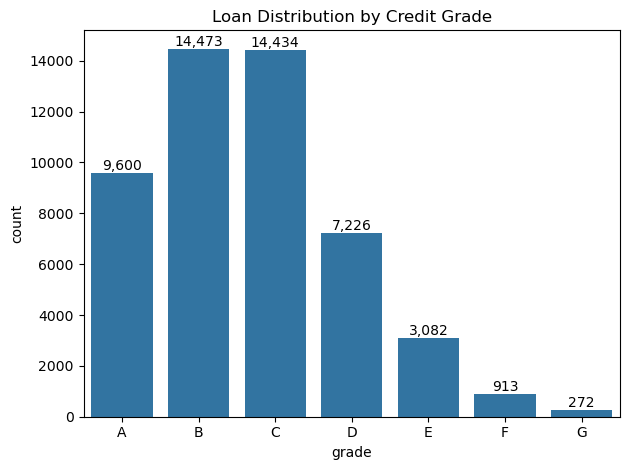

In [19]:
ax = sns.countplot(data=df, x="grade", order=sorted(df["grade"].unique()))

for p in ax.patches:
    ax.annotate(
        format(int(p.get_height()), ','),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title("Loan Distribution by Credit Grade")
plt.tight_layout()
plt.show()

In [21]:
df["default_flag"] = df["loan_status"].apply(
    lambda x: 1 if x == "Charged Off" else 0
)

In [22]:
df[["loan_status","default_flag"]].head()

,loan_status,default_flag
0,Fully Paid,0
1,Current,0
2,Fully Paid,0
3,Fully Paid,0
4,Current,0


In [23]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             23097
Current                                                20279
Charged Off                                             5778
Late (31-120 days)                                       487
In Grace Period                                          203
Late (16-30 days)                                         88
Does not meet the credit policy. Status:Fully Paid        43
Does not meet the credit policy. Status:Charged Off       24
Default                                                    1
Name: count, dtype: int64

In [24]:
df["default_flag"].value_counts()

default_flag
0    44222
1     5778
Name: count, dtype: int64

In [25]:
df["default_flag"] = df["loan_status"].isin(
    ["Charged Off", "Default"]
).astype(int)

In [26]:
df.groupby("loan_status")["default_flag"].mean()

loan_status
Charged Off                                            1.0
Current                                                0.0
Default                                                1.0
Does not meet the credit policy. Status:Charged Off    0.0
Does not meet the credit policy. Status:Fully Paid     0.0
Fully Paid                                             0.0
In Grace Period                                        0.0
Late (16-30 days)                                      0.0
Late (31-120 days)                                     0.0
Name: default_flag, dtype: float64

In [27]:
df["default_flag"] = df["loan_status"].str.contains(
    "Charged Off|Default",
    case=False,
    na=False
).astype(int)

In [28]:
df["default_flag"].value_counts()

default_flag
0    44197
1     5803
Name: count, dtype: int64

In [29]:
df.groupby("loan_status")["default_flag"].mean()

loan_status
Charged Off                                            1.0
Current                                                0.0
Default                                                1.0
Does not meet the credit policy. Status:Charged Off    1.0
Does not meet the credit policy. Status:Fully Paid     0.0
Fully Paid                                             0.0
In Grace Period                                        0.0
Late (16-30 days)                                      0.0
Late (31-120 days)                                     0.0
Name: default_flag, dtype: float64

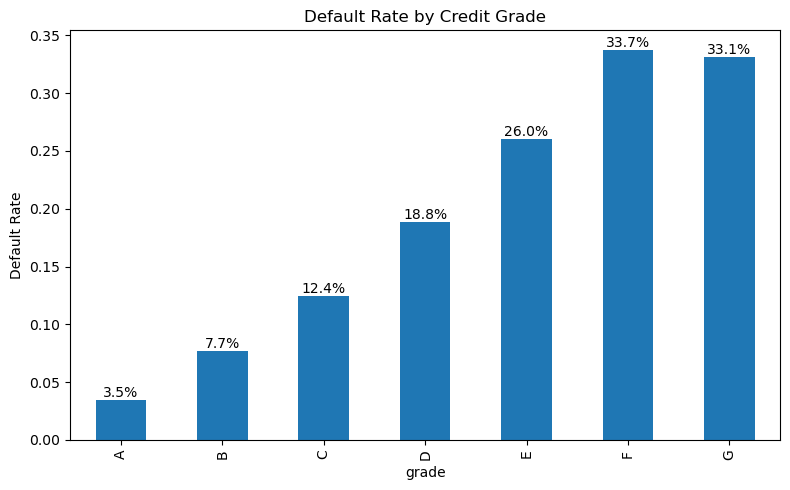

In [30]:
default_rate_grade = df.groupby("grade")["default_flag"].mean().sort_index()

plt.figure(figsize=(8,5))
ax = default_rate_grade.plot(kind="bar")

plt.title("Default Rate by Credit Grade")
plt.ylabel("Default Rate")

# Add labels
for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.1%}",
        (p.get_x() + p.get_width()/2, value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

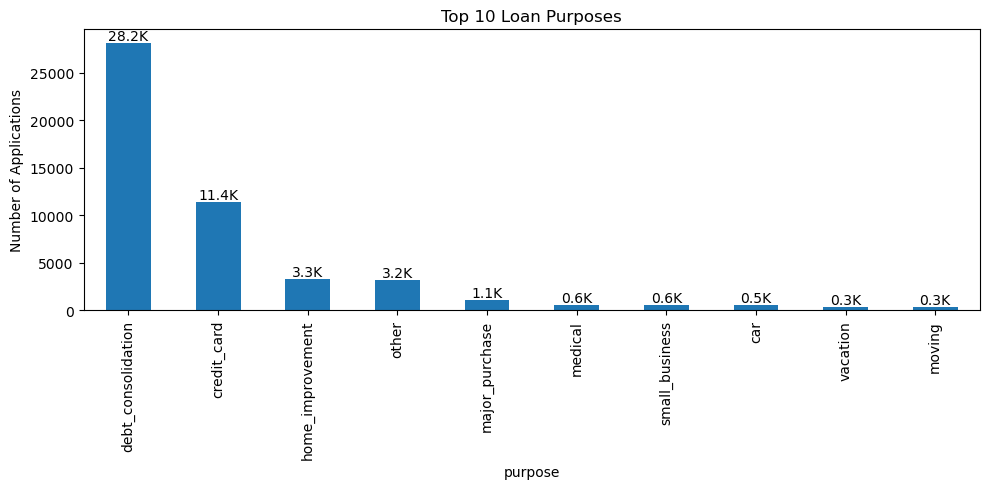

In [31]:
top_purpose = df["purpose"].value_counts().head(10)

plt.figure(figsize=(10,5))
ax = top_purpose.plot(kind="bar")

plt.title("Top 10 Loan Purposes")
plt.ylabel("Number of Applications")

# Add labels in thousands
for p in ax.patches:
    value = int(p.get_height())
    ax.annotate(
        f"{value/1000:.1f}K",
        (p.get_x() + p.get_width()/2, value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [33]:
df["dti_group"] = pd.cut(
    df["dti"],
    bins=[0,10,20,30,40,100],
    labels=["0-10","10-20","20-30","30-40","40+"]
)

In [34]:
df[["dti","dti_group"]].head()

,dti,dti_group
0,3.51,0-10
1,22.85,20-30
2,6.71,0-10
3,15.50,10-20
4,19.88,10-20


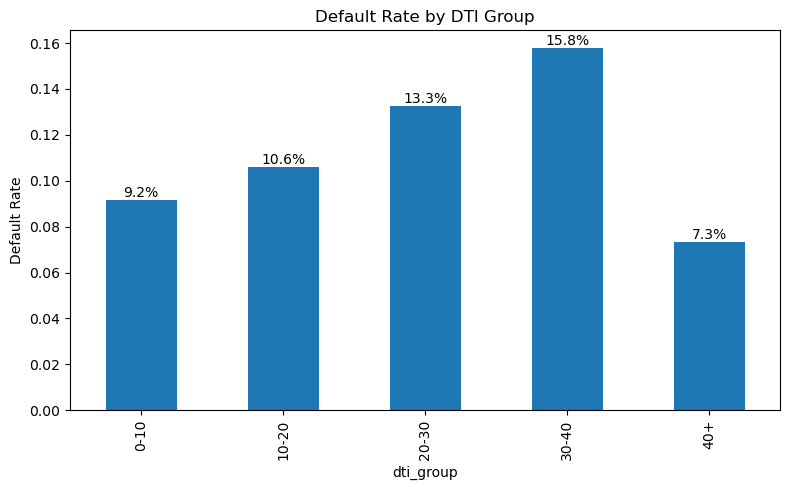

In [36]:
dti_default = df.groupby("dti_group", observed=False)["default_flag"].mean()

plt.figure(figsize=(8,5))
ax = dti_default.plot(kind="bar")

plt.title("Default Rate by DTI Group")
plt.ylabel("Default Rate")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.1%}",
        (p.get_x() + p.get_width()/2, value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()